## DEM


In [ ]:
## unzip *DEM*

import zipfile
import os

zip_path = "/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/GIS_Data/USGSElevation.zip"
extract_folder = "dem_extract"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print(os.listdir(extract_folder))

['USGSEle20s']


In [25]:
import geopandas as gpd
import rasterio
from pathlib import Path
from shapely.geometry import box

units = gpd.read_file("/content/drive/MyDrive/Data/tl_2025_48_tract/tl_2025_48_tract.shp")

units = units.to_crs("EPSG:4269")

texas_boundary = units.dissolve().geometry.iloc[0]

dem_folder = Path("/content/dem_extract/USGSEle20s")

selected_files = []

for tif in dem_folder.rglob("*.tif"):
    with rasterio.open(tif) as src:
        b = src.bounds
        tile_box = box(b.left, b.bottom, b.right, b.top)

    if tile_box.intersects(texas_boundary):
        selected_files.append(str(tif))

print("Selected DEM tiles:", len(selected_files))
selected_files[:5]

Selected DEM tiles: 94


['/content/dem_extract/USGSEle20s/USGS_1_n30w096_20240229.tif',
 '/content/dem_extract/USGSEle20s/USGS_1_n28w099_20211103.tif',
 '/content/dem_extract/USGSEle20s/USGS_1_n36w101_20250104.tif',
 '/content/dem_extract/USGSEle20s/USGS_1_n36w104_20210624.tif',
 '/content/dem_extract/USGSEle20s/USGS_1_n28w098_20190730.tif']

<Axes: >

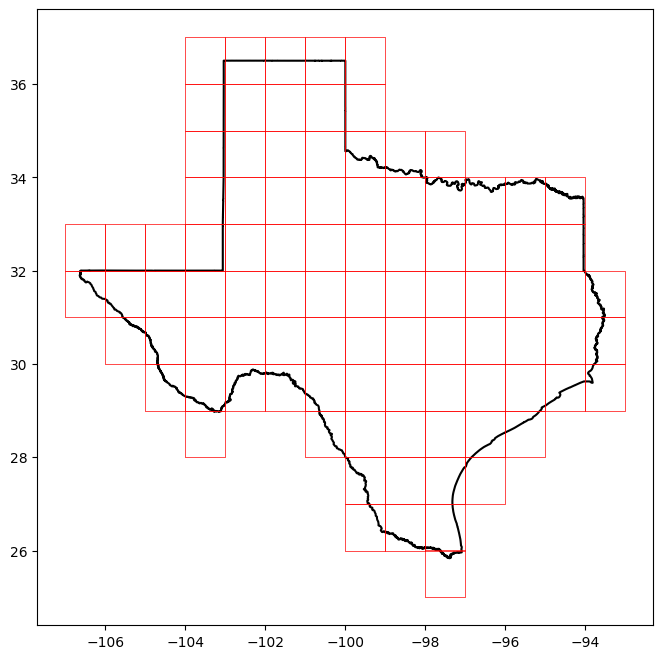

In [26]:
import geopandas as gpd
from shapely.geometry import box
import rasterio

tiles = []

for tif in selected_files:

    with rasterio.open(tif) as src:
        b = src.bounds

    tiles.append(
        box(
            b.left,
            b.bottom,
            b.right,
            b.top
        )
    )

tiles_gdf = gpd.GeoDataFrame(
    geometry=tiles,
    crs="EPSG:4269"
)

ax = units.dissolve().boundary.plot(
    figsize=(8,8),
    color="black"
)

tiles_gdf.boundary.plot(
    ax=ax,
    color="red",
    linewidth=0.5
)

## 1. Configuration and Imports

In [38]:
from pathlib import Path
import ast, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling
from rasterio.features import geometry_mask
from rasterio.warp import reproject
import torch

from semantic_tweet_raster import (
    HARVEY_TARGET_NAMES, BERTMultiDeepHeadClassifier, clean_tweet_text,
    normalize_channels, predict_tweet_impacts, prepare_tweet_bounding_boxes,
    rasterize_semantic_predictions, resample_multiband_to_match,
    set_reproducibility, write_multiband_geotiff,
)
from flood_unet import (
    UNet, build_spatial_fold_map, predict_full_map_overlap,
    run_spatial_cv_experiment, train_final_model,
)

# None means unresolved: set it here before running dependent sections.
CONFIG = {
    "tweet_csv": '/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Yalong/GRIIDC data/with zip code/Copy of harvey_with_zipcode.csv',
    "water_depth_target_0025":     "/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Yuning/weather_grid_01deg/HGAC_ERA5wind_PRISMprecip_overlay_zoom/HGAC_0p025_grid_tifs/grid_waterDepth_0025.tif",
    "coarse_water_depth_01":     "/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Yuning/weather_grid_01deg/HGAC_ERA5wind_PRISMprecip_overlay_zoom/HGAC_0p025_grid_tifs/grid_waterDepth_01.tif",
    "precipitation_raster":     "/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Yuning/Grid_Texas/ERA5wind_PRISMprecip_Texas/Texas_0p025_grid_tifs/Texas_PRISM_cumulative_precip_mean_mm_0p025deg.tif",
    "wind_raster":     "/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Yuning/Grid_Texas/ERA5wind_PRISMprecip_Texas/Texas_0p025_grid_tifs/Texas_ERA5_max_wind_kts_0p025deg.tif",
    "dem_tiles": tiles,
    "texas_boundary_file": texas_boundary,
    # Explicitly preserved from harvey_bert_multihead_deep_5fold.ipynb:
    "model_checkpoint_dir": Path("/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Akash/Source_Code/Training_results/harvey_5foldcv_BERT_Multihead_512"),
    "checkpoint_pattern": "best_bert_model_fold_{fold}.pth",
    "tokenizer_name": "bert-base-uncased",
    "text_col": "text",
    "place_col": "place",
    "lon_min_col": "lon_min", "lat_min_col": "lat_min",
    "lon_max_col": "lon_max", "lat_max_col": "lat_max",
    "texas_extent": (-107.0, -93.0, 25.0, 37.0),  # lon min/max, lat min/max
    "grid_resolution": 0.025,
    "target_names": HARVEY_TARGET_NAMES,
    "inference_batch_size": 64,
    "max_token_length": 128,
    "num_folds": 5,
    "patch_size": 64, "stride": 32,
    "unet_batch_size": 4,
    "learning_rate": 1e-4, "epochs": 50,
    "early_stopping_patience": 10, "min_delta": 1e-4,
    "smoothness_weight": 0.001,
    "random_seed": 42,
    "semantic_mean_path": Path("outputs/texas_semantic_mean_0025.tif"),
    "semantic_sum_path": Path("outputs/texas_semantic_sum_0025.tif"),
    "semantic_weight_path": Path("outputs/texas_semantic_weight_0025.tif"),
    "tweet_count_path": Path("outputs/texas_tweet_count_0025.tif"),
    "cv_results_path": Path("outputs/ablation_fold_results.csv"),
    "cv_summary_path": Path("outputs/ablation_summary.csv"),
    "final_model_path": Path("outputs/final_unet_all_data.pth"),
    "prediction_path": Path("outputs/pred_full_texas.tif"),
    "model_output_dir": Path("outputs/models"),
}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CONFIG["device"] = DEVICE
print("Device:", DEVICE)

Device: cuda


## 2. Reproducibility

In [39]:
set_reproducibility(CONFIG["random_seed"])
print("Seed:", CONFIG["random_seed"])

Seed: 42


## 3. Load Tweets

In [40]:
def require_path(value, label):
    if value is None:
        raise FileNotFoundError(f"Set CONFIG[{label!r}] before running this section.")
    path = Path(value)
    if not path.exists():
        raise FileNotFoundError(f"{label} does not exist: {path}")
    return path

def parse_bbox(value):
    """Parse the source notebook's dict-like `place` or four-number bbox."""
    try:
        parsed = ast.literal_eval(str(value))
        if isinstance(parsed, dict) and len(parsed.get("bbox", [])) == 4:
            return tuple(map(float, parsed["bbox"]))
    except (ValueError, SyntaxError, TypeError):
        pass
    try:
        parts = [float(x.strip("()[] '\"")) for x in str(value).split(",")]
        return tuple(parts) if len(parts) == 4 else None
    except ValueError:
        return None

tweet_path = require_path(CONFIG["tweet_csv"], "tweet_csv")
raw_tweets = pd.read_csv(tweet_path, low_memory=False)
if raw_tweets.empty:
    raise ValueError("Tweet CSV is empty.")
if CONFIG["place_col"] in raw_tweets and not {
    CONFIG["lon_min_col"], CONFIG["lat_min_col"], CONFIG["lon_max_col"], CONFIG["lat_max_col"]
}.issubset(raw_tweets.columns):
    parsed = raw_tweets[CONFIG["place_col"]].map(parse_bbox)
    valid = parsed.notna()
    raw_tweets = raw_tweets.loc[valid].copy()
    raw_tweets[[CONFIG["lon_min_col"], CONFIG["lat_min_col"],
                CONFIG["lon_max_col"], CONFIG["lat_max_col"]]] = pd.DataFrame(
        parsed.loc[valid].tolist(), index=raw_tweets.index
    )
print("Loaded tweets:", len(raw_tweets))

Loaded tweets: 209004


## 4. Clean Text and Bounding Boxes

In [41]:
tweets, nrows, ncols, texas_transform, texas_crs = prepare_tweet_bounding_boxes(
    raw_tweets, CONFIG["text_col"], CONFIG["lon_min_col"], CONFIG["lat_min_col"],
    CONFIG["lon_max_col"], CONFIG["lat_max_col"], CONFIG["texas_extent"],
    CONFIG["grid_resolution"],
)
assert tweets["tweet_uid"].is_unique
print(tweets[["tweet_uid", "clean_text", "tweet_box_area_km2", "spatial_precision_weight"]].head())
print("Clean tweets:", len(tweets), "| grid:", nrows, "x", ncols)

   tweet_uid                                         clean_text  \
0          0  Latest ozonesonde balloon flight from Socorro,...   
1          1  Family and Faculty come together to recognize ...   
2          2  An awesome return of recognizing GOODER schola...   
3          3  Meet Mr. Alaniz one of the GOODER additions to...   
4          4  Have you already snagged this seasons ultimate...   

   tweet_box_area_km2  spatial_precision_weight  
0           93.433864                  0.102905  
1            0.000000                  1.000000  
2            0.000000                  1.000000  
3            0.000000                  1.000000  
4            0.000000                  1.000000  
Clean tweets: 208657 | grid: 480 x 560


## 5. Load BERT Multi-Head Model

The target order is preserved exactly from `harvey_bert_multihead_deep_5fold.ipynb`.
The checked-in loader also supports the two observed Harvey checkpoint head layouts:
`768→512→128→1` from the notebook and exported `768→256→1` fold files. It infers the
hidden dimensions from each checkpoint and still uses strict state-dict loading, so unrelated
or inconsistent checkpoints fail clearly. Both layouts end each head with a sigmoid, so
`BERTMultiDeepHeadClassifier.outputs_are_logits = False`; inference does not apply a second
sigmoid.

In [42]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained(CONFIG["tokenizer_name"])
checkpoint_paths = [
    Path(CONFIG["model_checkpoint_dir"]) / CONFIG["checkpoint_pattern"].format(fold=fold)
    for fold in range(1, CONFIG["num_folds"] + 1)
]
missing_checkpoints = [str(p) for p in checkpoint_paths if not p.is_file()]
if missing_checkpoints:
    raise FileNotFoundError("Missing Harvey fold checkpoints: " + ", ".join(missing_checkpoints))
print(*checkpoint_paths, sep="\n")

/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Akash/Source_Code/Training_results/harvey_5foldcv_BERT_Multihead_512/best_bert_model_fold_1.pth
/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Akash/Source_Code/Training_results/harvey_5foldcv_BERT_Multihead_512/best_bert_model_fold_2.pth
/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Akash/Source_Code/Training_results/harvey_5foldcv_BERT_Multihead_512/best_bert_model_fold_3.pth
/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Akash/Source_Code/Training_results/harvey_5foldcv_BERT_Multihead_512/best_bert_model_fold_4.pth
/content/drive/Shareddrives/TAMIDS Disaster Impact Estimation Prediction/Data/Akash/Source_Code/Training_results/harvey_5foldcv_BERT_Multihead_512/best_bert_model_fold_5.pth


## 6. Tweet-Level Disaster-Impact Inference

> **Methodological limitation:** this is a **tweet-level application of a model trained using
> ZIP-level aggregated disaster-impact labels**. The inference unit has changed. These
> probabilities must not be described as equivalent to predictions from a model trained and
> validated on individual tweet labels.

In [43]:
import sys
import importlib
import inspect

PROJECT_DIR = "/content/drive/MyDrive/DIEP"

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

import semantic_tweet_raster as straster

importlib.invalidate_caches()
straster = importlib.reload(straster)

print("Module path:")
print(straster.__file__)

print("\nModel signature:")
print(inspect.signature(straster.BERTMultiDeepHeadClassifier))

Module path:
/content/drive/MyDrive/DIEP/semantic_tweet_raster.py

Model signature:
(num_targets: 'int' = 11, bert_model: 'nn.Module | None' = None, pretrained_name: 'str' = 'bert-base-uncased', head_hidden_dims: 'Sequence[int]' = (512, 128))


In [45]:
single_checkpoint = [checkpoint_paths[0]]

In [46]:
impact_predictions = straster.predict_tweet_impacts(
    tweets=tweets,
    text_col="clean_text",
    tokenizer=tokenizer,
    model_class=straster.BERTMultiDeepHeadClassifier,
    checkpoint_paths=single_checkpoint,
    target_names=CONFIG["target_names"],
    device=DEVICE,
    batch_size=CONFIG["inference_batch_size"],
    max_length=CONFIG["max_token_length"],
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded best_bert_model_fold_1.pth: head hidden dimensions=(256,)
Prediction shape: (208657, 11)
                                  count      mean       std       min  \
homeOwnersInsurance            208657.0  0.725767  0.316492  0.022912   
floodInsurance                 208657.0  0.651979  0.351378  0.006835   
destroyed                      208657.0  0.159812  0.321137  0.001442   
floodDamage                    208657.0  0.630501  0.411411  0.001686   
roofDamage                     208657.0  0.647414  0.410520  0.001165   
tsaEligible                    208657.0  0.898158  0.157382  0.012724   
tsaCheckedIn                   208657.0  0.592269  0.393774  0.003077   
rentalAssistanceEligible       208657.0  0.599292  0.414851  0.001789   
repairAssistanceEligible       208657.0  0.636905  0.415704  0.001059   
replacementAssistanceEligible  208657.0  0.062543  0.220297  0.000426   
personalPropertyEligible       208657.0  0.611773  0.401958  0.002572   

                           

In [47]:
if len(impact_predictions) != len(tweets):
    raise ValueError("Prediction/dataframe row mismatch.")

if not impact_predictions.index.equals(tweets.index):
    raise ValueError("Prediction and tweet indices are not aligned.")

tweets = tweets.join(
    impact_predictions,
    validate="one_to_one",
)

assert np.isfinite(
    tweets[CONFIG["target_names"]].to_numpy()
).all()

## 7. Semantic Rasterization

In [48]:
semantic_sum, semantic_weight, semantic_mean, tweet_count_raster = rasterize_semantic_predictions(
    tweets, CONFIG["target_names"], nrows, ncols, aggregation="mean"
)
assert semantic_mean.shape == (len(CONFIG["target_names"]), nrows, ncols)
write_multiband_geotiff(CONFIG["semantic_mean_path"], semantic_mean, texas_transform, texas_crs, CONFIG["target_names"])
write_multiband_geotiff(CONFIG["semantic_weight_path"], semantic_weight, texas_transform, texas_crs, ["semantic_weight"])
write_multiband_geotiff(CONFIG["tweet_count_path"], tweet_count_raster, texas_transform, texas_crs, ["tweet_count"])
# Optional diagnostic sum cube:
write_multiband_geotiff(CONFIG["semantic_sum_path"], semantic_sum, texas_transform, texas_crs, CONFIG["target_names"])

Saved: outputs/texas_semantic_mean_0025.tif | dimensions=560x480 | bands=11
homeOwnersInsurance: min=0, max=0.997491, mean=0.619491, std=0.27348, nonzero=83.75%
floodInsurance: min=0, max=0.996757, mean=0.556242, std=0.245878, nonzero=83.75%
destroyed: min=0, max=0.998686, mean=0.125813, std=0.0594405, nonzero=83.75%
floodDamage: min=0, max=0.998936, mean=0.543084, std=0.240397, nonzero=83.75%
roofDamage: min=0, max=0.999016, mean=0.557134, std=0.246526, nonzero=83.75%
tsaEligible: min=0, max=0.996481, mean=0.753643, std=0.332045, nonzero=83.75%
tsaCheckedIn: min=0, max=0.997994, mean=0.506694, std=0.22441, nonzero=83.75%
rentalAssistanceEligible: min=0, max=0.998792, mean=0.516183, std=0.228677, nonzero=83.75%
repairAssistanceEligible: min=0, max=0.999183, mean=0.548352, std=0.242713, nonzero=83.75%
replacementAssistanceEligible: min=0, max=0.984991, mean=0.0475361, std=0.0248084, nonzero=83.75%
personalPropertyEligible: min=0, max=0.99845, mean=0.524259, std=0.232123, nonzero=83.75%


PosixPath('outputs/texas_semantic_sum_0025.tif')

## 8. Semantic Raster Quality Control

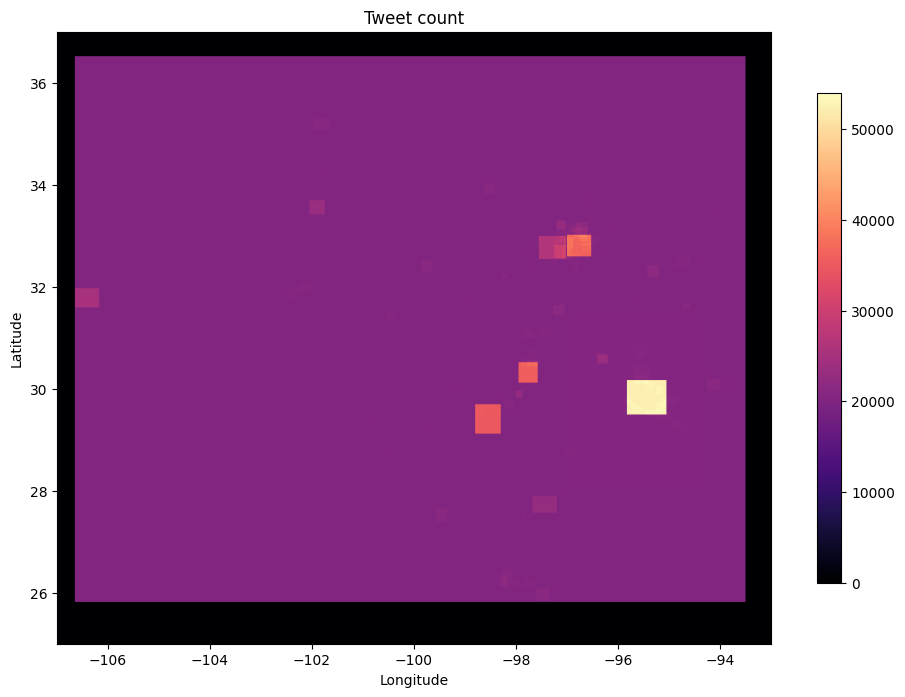

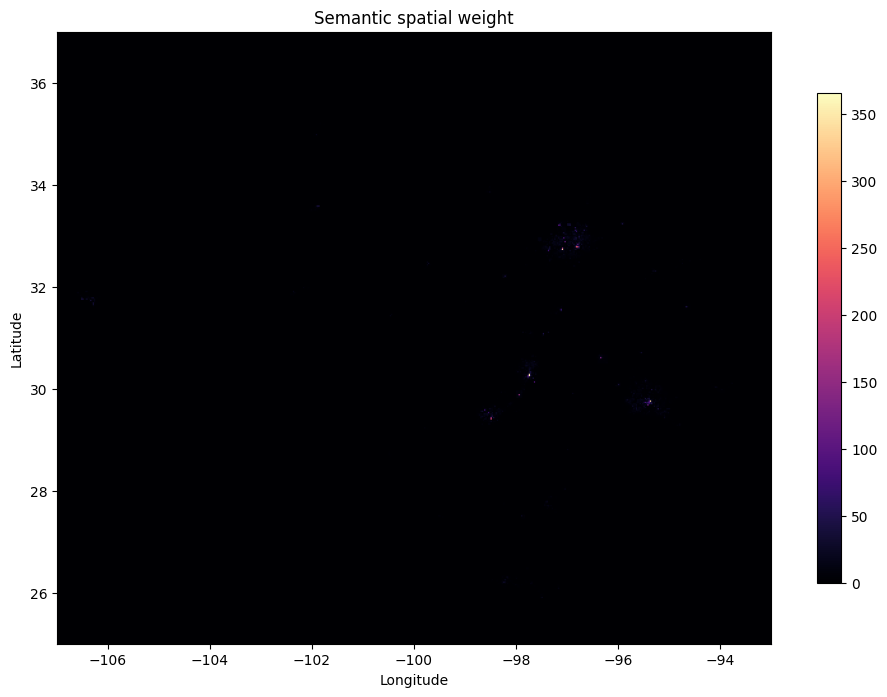

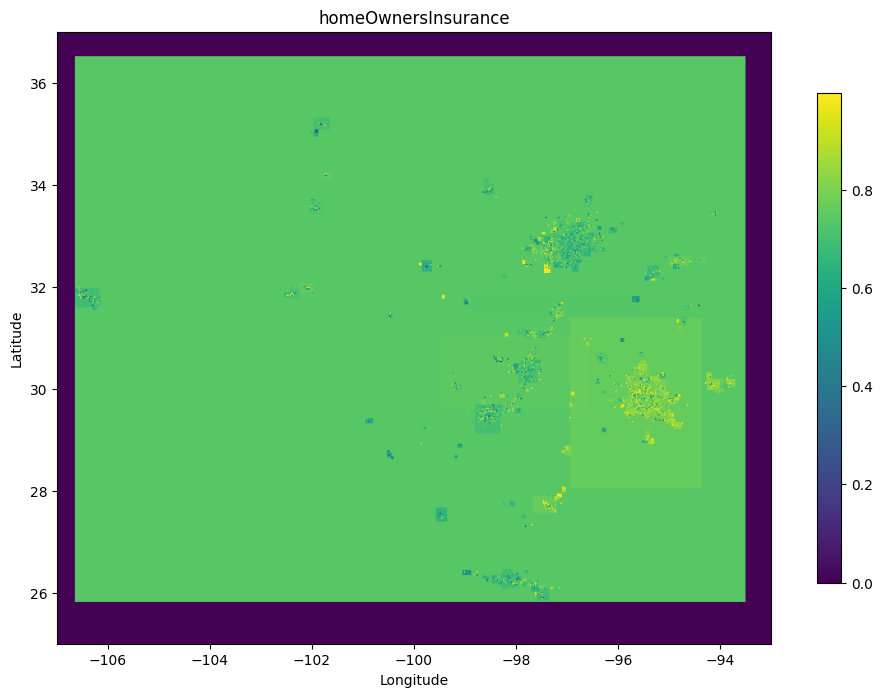

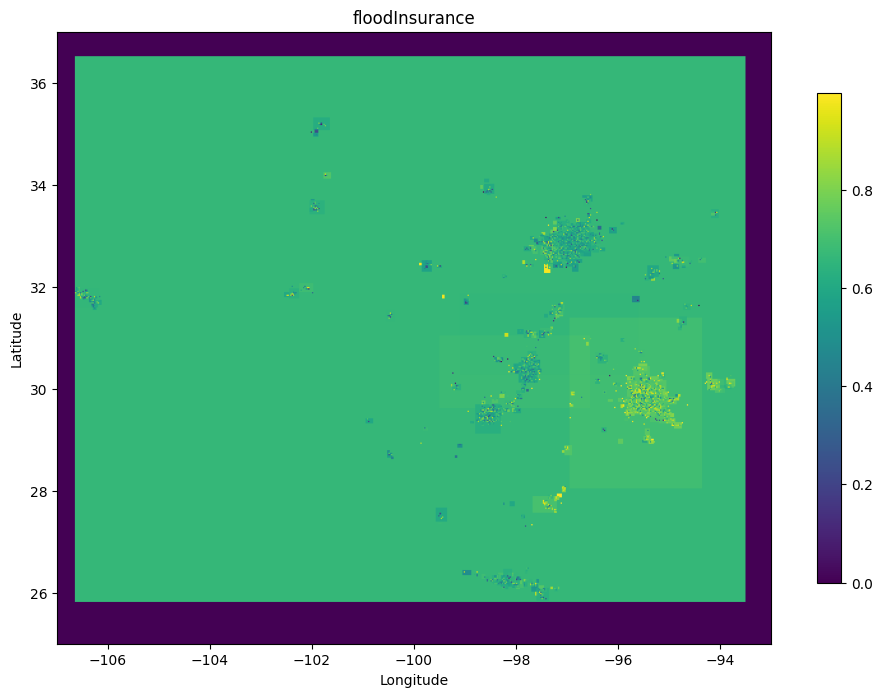

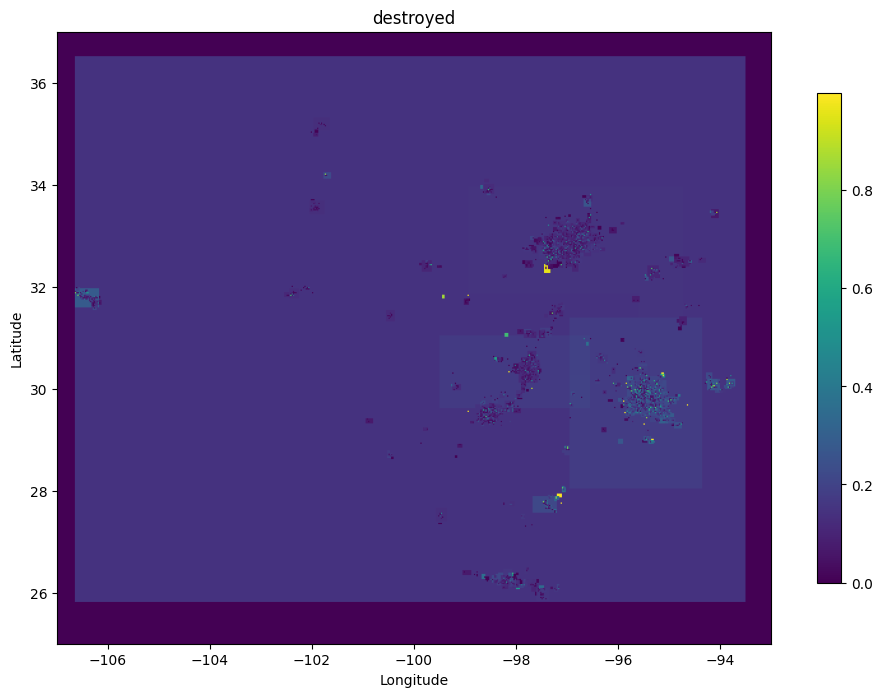

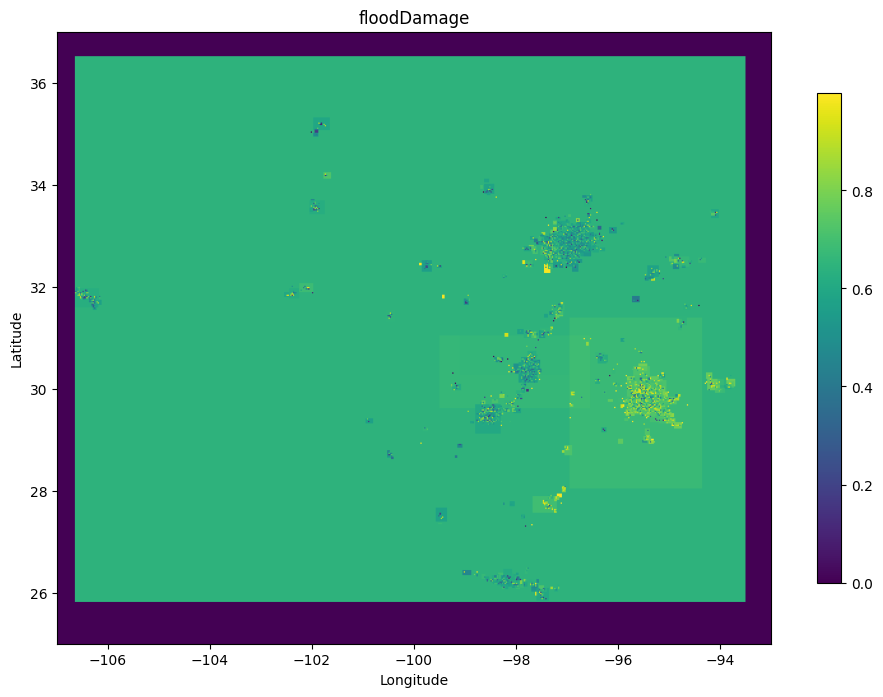

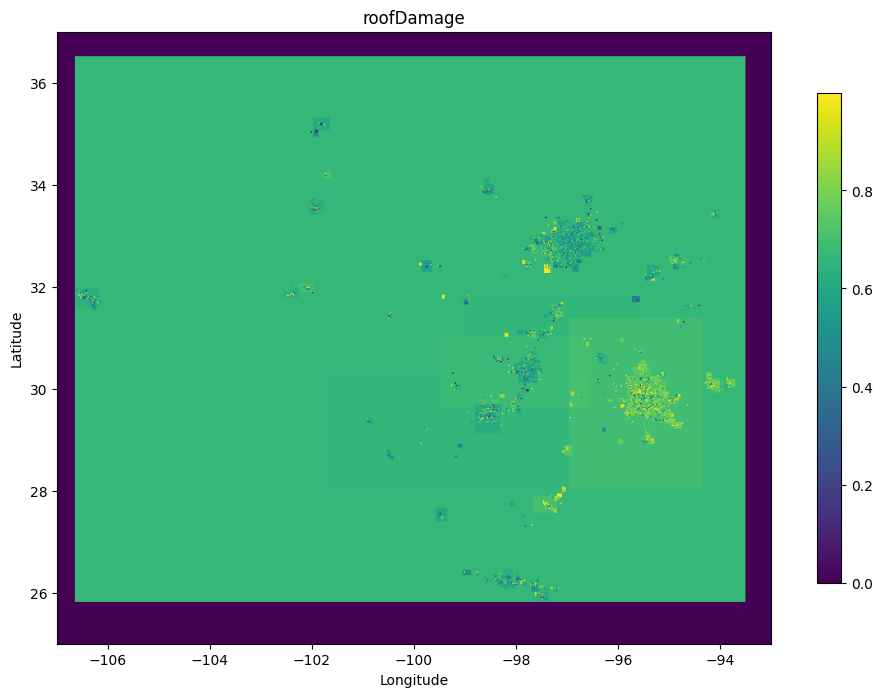

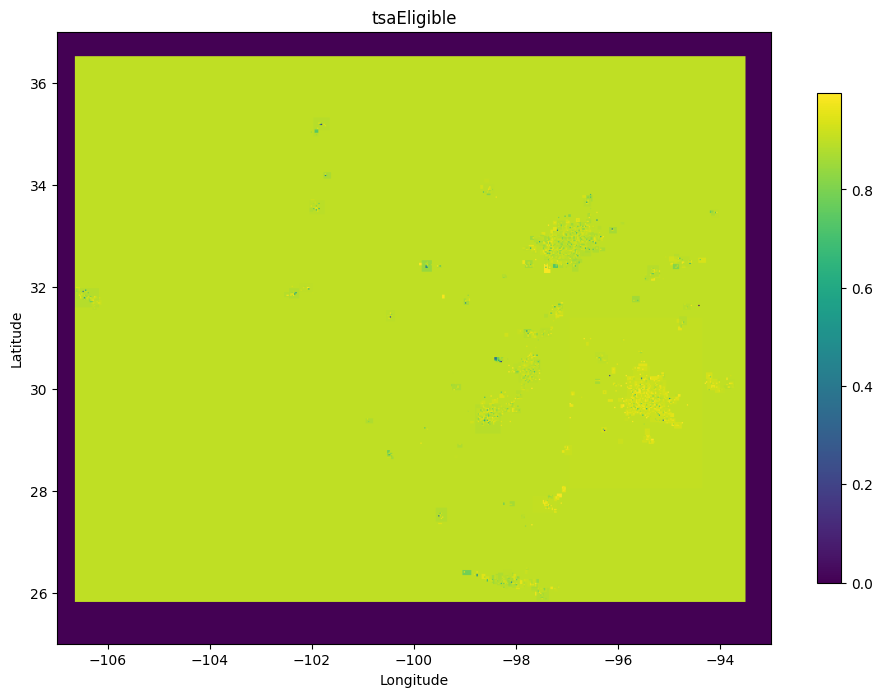

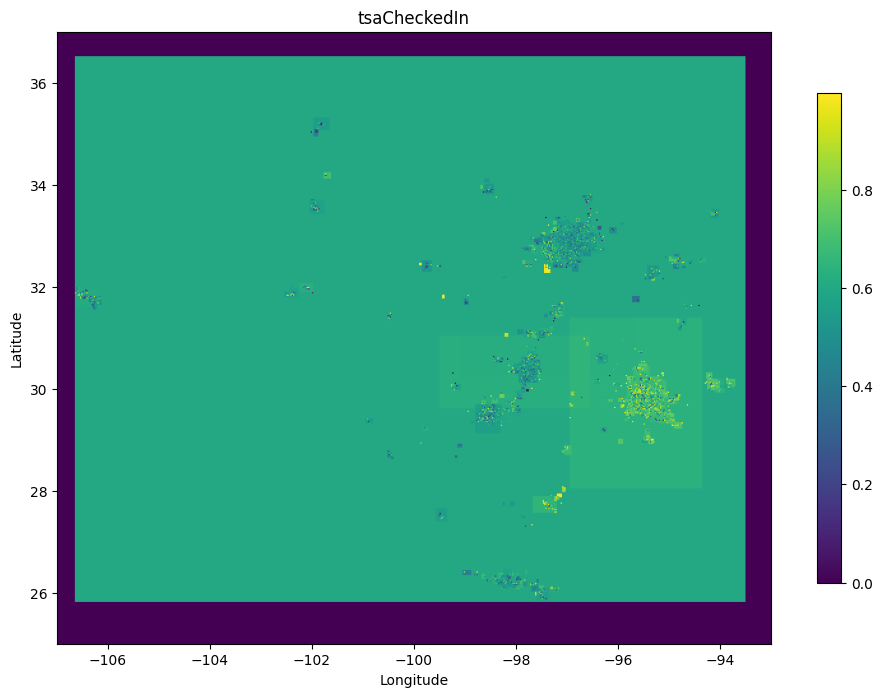

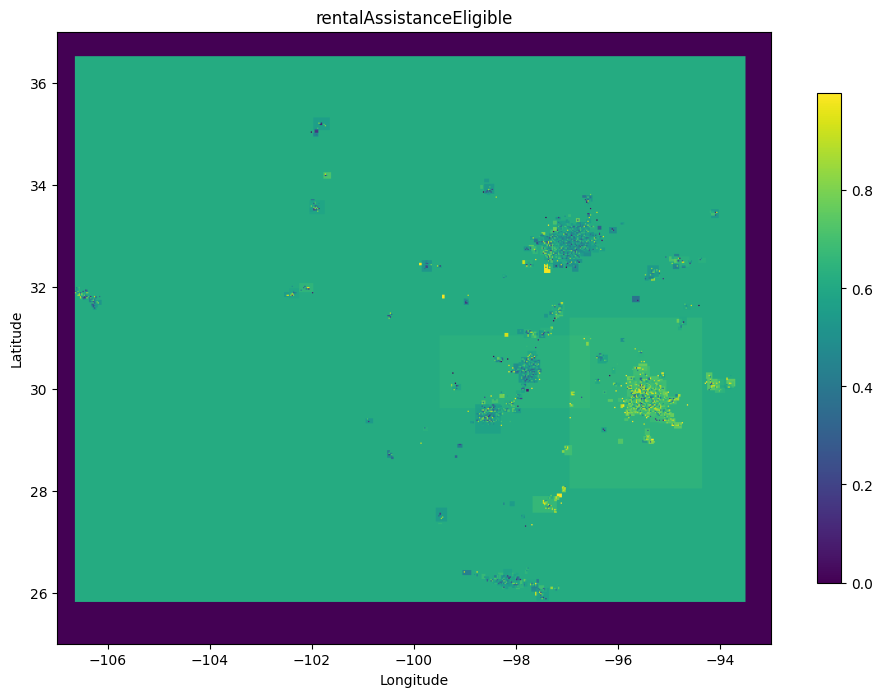

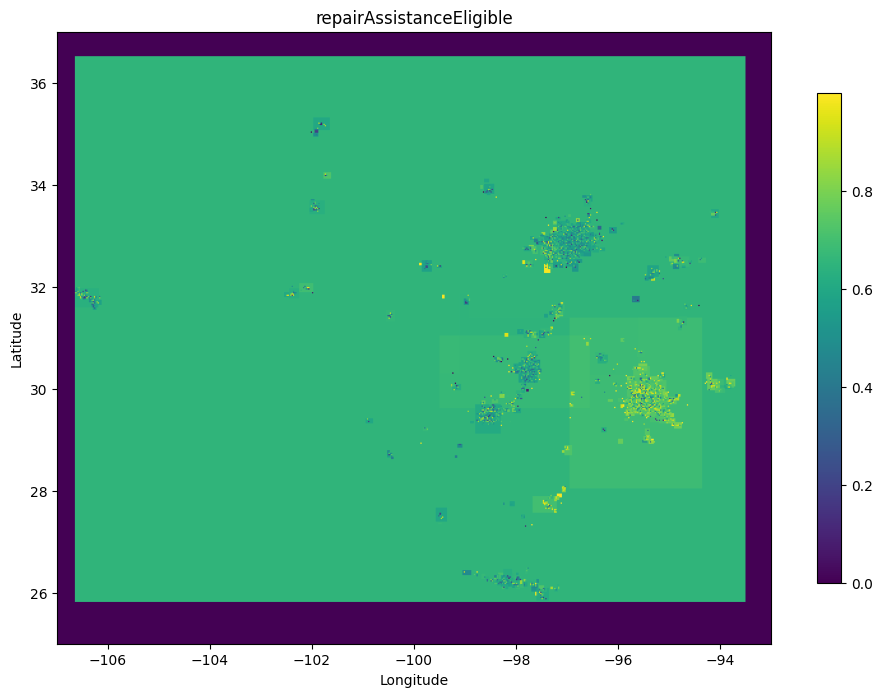

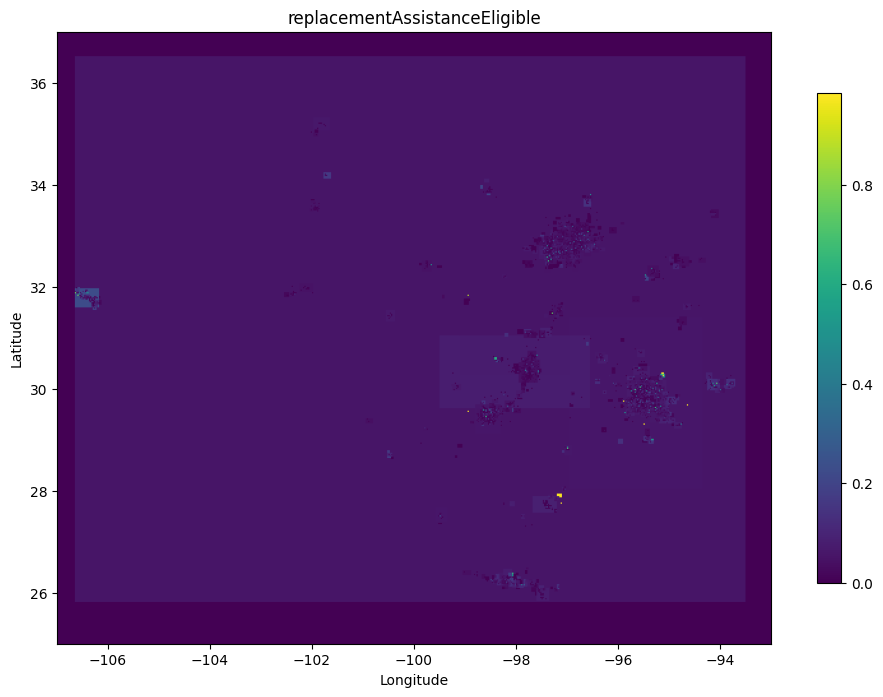

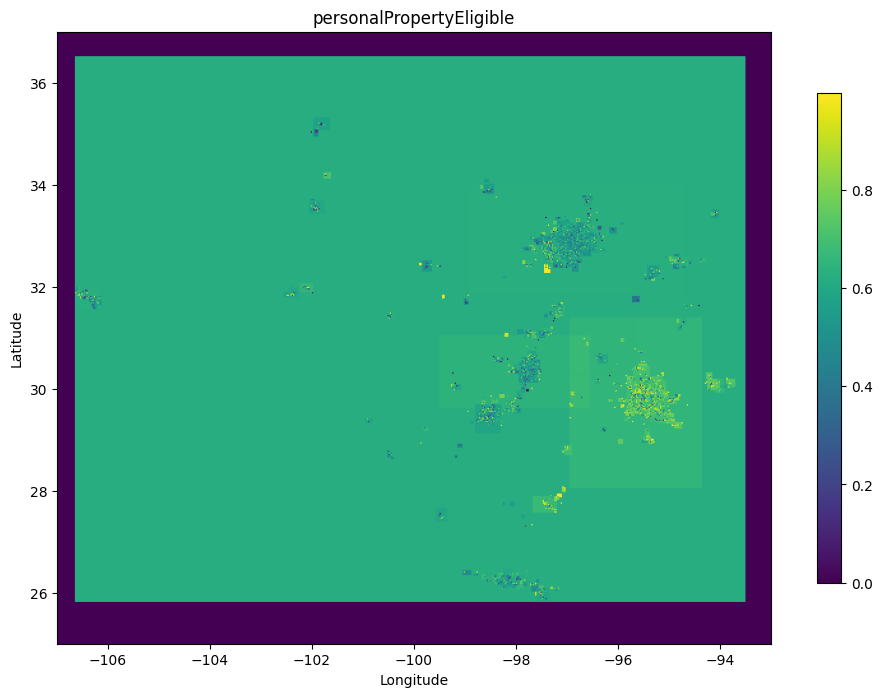

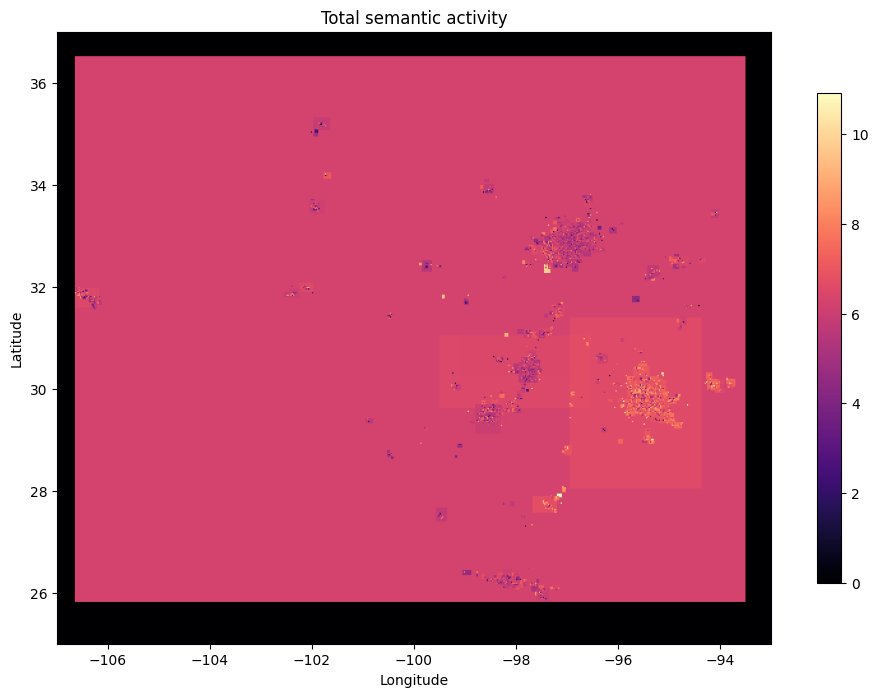

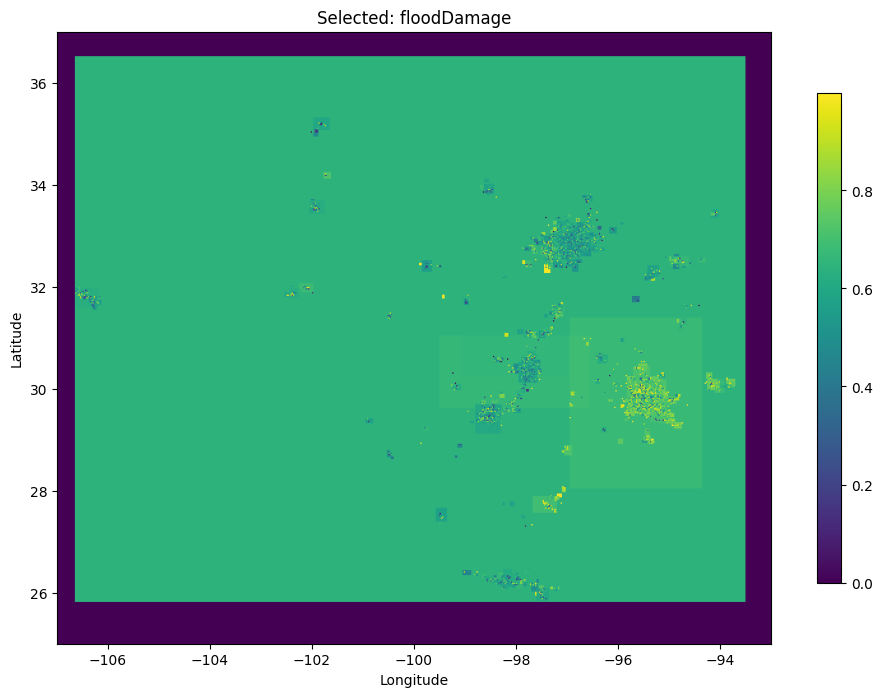

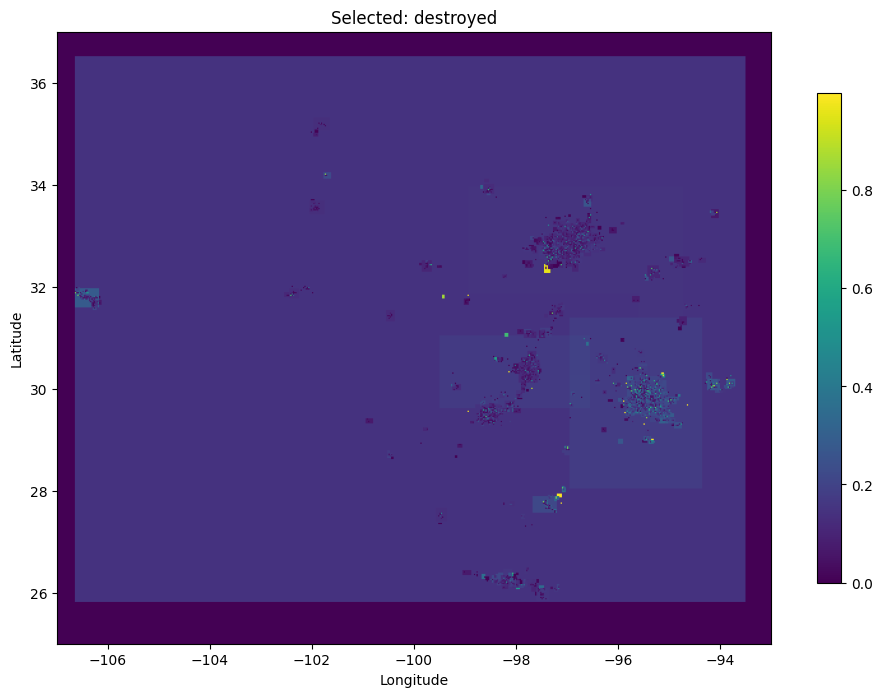

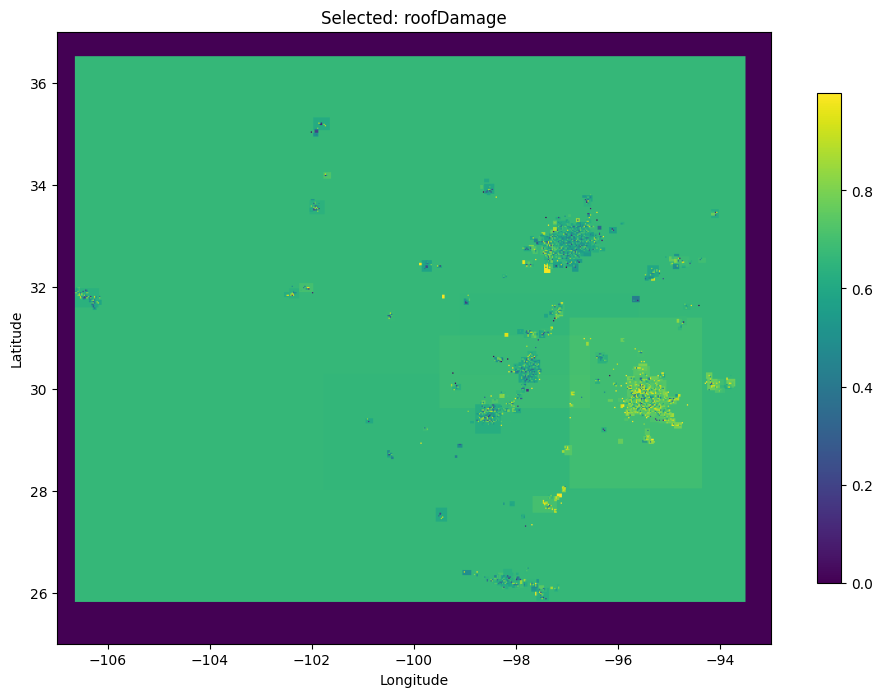

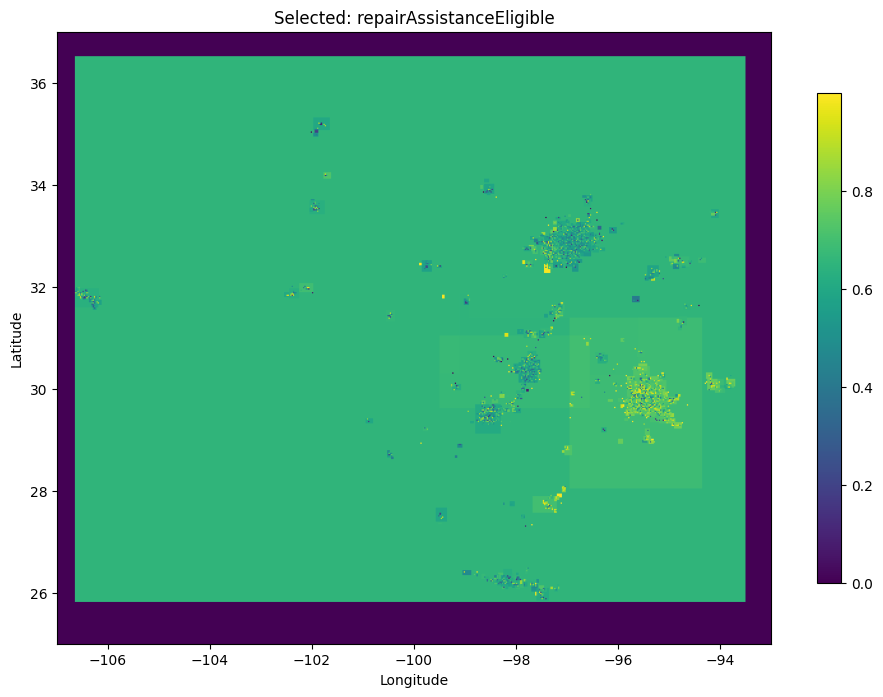

In [49]:
extent_plot = [CONFIG["texas_extent"][0], CONFIG["texas_extent"][1],
               CONFIG["texas_extent"][2], CONFIG["texas_extent"][3]]
def show_raster(array, title, cmap="viridis"):
    plt.figure(figsize=(10, 7))
    plt.imshow(array, extent=extent_plot, origin="upper", cmap=cmap)
    plt.title(title); plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.colorbar(shrink=.8); plt.tight_layout(); plt.show()

show_raster(tweet_count_raster, "Tweet count", "magma")
show_raster(semantic_weight, "Semantic spatial weight", "magma")
for name, band in zip(CONFIG["target_names"], semantic_mean):
    show_raster(band, name)
show_raster(semantic_mean.sum(axis=0), "Total semantic activity", "magma")
for selected in ("floodDamage", "destroyed", "roofDamage", "repairAssistanceEligible"):
    if selected in CONFIG["target_names"]:
        show_raster(semantic_mean[CONFIG["target_names"].index(selected)], f"Selected: {selected}")

In [51]:
print("Semantic raster shape:", semantic_mean.shape)
print("Rows:", nrows)
print("Columns:", ncols)
print("Resolution:", CONFIG["grid_resolution"], "degrees")
print("Transform:", texas_transform)
print("CRS:", texas_crs)

Semantic raster shape: (11, 480, 560)
Rows: 480
Columns: 560
Resolution: 0.025 degrees
Transform: | 0.03, 0.00,-107.00|
| 0.00,-0.03, 37.00|
| 0.00, 0.00, 1.00|
CRS: EPSG:4326


In [52]:
print("X resolution:", repr(texas_transform.a))
print("Y resolution:", repr(abs(texas_transform.e)))
print("Full transform tuple:", tuple(texas_transform))

X resolution: 0.025
Y resolution: 0.025
Full transform tuple: (0.025, 0.0, -107.0, 0.0, -0.025, 37.0, 0.0, 0.0, 1.0)


In [53]:
from pathlib import Path

paths_to_check = {
    "semantic mean": CONFIG["semantic_mean_path"],
    "semantic sum": CONFIG["semantic_sum_path"],
    "semantic weight": CONFIG["semantic_weight_path"],
    "tweet count": CONFIG["tweet_count_path"],
}

for name, path_value in paths_to_check.items():
    path = Path(path_value)
    print(
        name,
        "| exists:", path.exists(),
        "| path:", path.resolve(),
        "| size MB:",
        round(path.stat().st_size / 1024**2, 2)
        if path.exists() else "N/A",
    )

semantic mean | exists: True | path: /content/drive/MyDrive/DIEP/outputs/texas_semantic_mean_0025.tif | size MB: 1.5
semantic sum | exists: True | path: /content/drive/MyDrive/DIEP/outputs/texas_semantic_sum_0025.tif | size MB: 1.52
semantic weight | exists: True | path: /content/drive/MyDrive/DIEP/outputs/texas_semantic_weight_0025.tif | size MB: 0.08
tweet count | exists: True | path: /content/drive/MyDrive/DIEP/outputs/texas_tweet_count_0025.tif | size MB: 0.07


In [54]:
import rasterio

with rasterio.open(
    CONFIG["semantic_mean_path"]
) as src:
    print("Number of bands:", src.count)
    print("Band names:")

    for band_index, description in enumerate(
        src.descriptions,
        start=1,
    ):
        print(band_index, description)

Number of bands: 11
Band names:
1 homeOwnersInsurance
2 floodInsurance
3 destroyed
4 floodDamage
5 roofDamage
6 tsaEligible
7 tsaCheckedIn
8 rentalAssistanceEligible
9 repairAssistanceEligible
10 replacementAssistanceEligible
11 personalPropertyEligible


## 9. Environmental Raster Preprocessing

In [56]:
from pathlib import Path

CONFIG["dem_tiles"] = [
    Path(path)
    for path in selected_files
]

print("DEM tiles:", len(CONFIG["dem_tiles"]))
print(CONFIG["dem_tiles"][:5])

DEM tiles: 94
[PosixPath('/content/dem_extract/USGSEle20s/USGS_1_n30w096_20240229.tif'), PosixPath('/content/dem_extract/USGSEle20s/USGS_1_n28w099_20211103.tif'), PosixPath('/content/dem_extract/USGSEle20s/USGS_1_n36w101_20250104.tif'), PosixPath('/content/dem_extract/USGSEle20s/USGS_1_n36w104_20210624.tif'), PosixPath('/content/dem_extract/USGSEle20s/USGS_1_n28w098_20190730.tif')]


In [57]:
def read_raster(path_value, label):
    path = require_path(path_value, label)
    with rasterio.open(path) as src:
        array = src.read(1).astype(np.float32)
        profile, transform, crs, nodata = src.profile.copy(), src.transform, src.crs, src.nodata
    if nodata is not None:
        array[array == nodata] = np.nan
    array[array <= -9999] = np.nan
    return array, profile, transform, crs

def resample_single(array, transform, crs, target_profile):
    cube = resample_multiband_to_match(array[None], transform, crs, target_profile)
    return cube[0]

water_025, target_profile, water_025_transform, water_025_crs = read_raster(
    CONFIG["water_depth_target_0025"], "water_depth_target_0025")
water_01, _, water_01_transform, water_01_crs = read_raster(
    CONFIG["coarse_water_depth_01"], "coarse_water_depth_01")
precip_raw, _, precip_transform, precip_crs = read_raster(
    CONFIG["precipitation_raster"], "precipitation_raster")
wind_raw, _, wind_transform, wind_crs = read_raster(CONFIG["wind_raster"], "wind_raster")

def build_dem_resampled_from_tiles(paths, profile):
    if not paths:
        raise FileNotFoundError("Set CONFIG['dem_tiles'] to one or more DEM GeoTIFFs.")
    total = np.zeros((profile["height"], profile["width"]), np.float32)
    count = np.zeros_like(total)
    for path in paths:
        dem, _, transform, crs = read_raster(path, "dem_tile")
        aligned = resample_single(dem, transform, crs, profile)
        valid = np.isfinite(aligned); total[valid] += aligned[valid]; count[valid] += 1
    result = np.full_like(total, np.nan); np.divide(total, count, out=result, where=count > 0)
    return result

water_01_up = resample_single(water_01, water_01_transform, water_01_crs, target_profile)
precip_025 = resample_single(precip_raw, precip_transform, precip_crs, target_profile)
wind_025 = resample_single(wind_raw, wind_transform, wind_crs, target_profile)
dem_025 = build_dem_resampled_from_tiles(CONFIG["dem_tiles"], target_profile)
dy, dx = np.gradient(dem_025, 550.0)
slope_025 = np.sqrt(dx**2 + dy**2).astype(np.float32)

Source: (1, 429, 528) EPSG:4326 | 0.03, 0.00,-106.65|
| 0.00,-0.03, 36.54|
| 0.00, 0.00, 1.00|
Target: (1, 427, 527) EPSG:4326 | 0.03, 0.00,-106.65|
| 0.00,-0.03, 36.51|
| 0.00, 0.00, 1.00|
Source: (1, 480, 560) EPSG:4326 | 0.03, 0.00,-107.00|
| 0.00,-0.03, 37.00|
| 0.00, 0.00, 1.00|
Target: (1, 427, 527) EPSG:4326 | 0.03, 0.00,-106.65|
| 0.00,-0.03, 36.51|
| 0.00, 0.00, 1.00|
Source: (1, 480, 560) EPSG:4326 | 0.03, 0.00,-107.00|
| 0.00,-0.03, 37.00|
| 0.00, 0.00, 1.00|
Target: (1, 427, 527) EPSG:4326 | 0.03, 0.00,-106.65|
| 0.00,-0.03, 36.51|
| 0.00, 0.00, 1.00|
Source: (1, 3612, 3612) EPSG:4269 | 0.00, 0.00,-96.00|
| 0.00,-0.00, 30.00|
| 0.00, 0.00, 1.00|
Target: (1, 427, 527) EPSG:4326 | 0.03, 0.00,-106.65|
| 0.00,-0.03, 36.51|
| 0.00, 0.00, 1.00|
Source: (1, 3612, 3612) EPSG:4269 | 0.00, 0.00,-99.00|
| 0.00,-0.00, 28.00|
| 0.00, 0.00, 1.00|
Target: (1, 427, 527) EPSG:4326 | 0.03, 0.00,-106.65|
| 0.00,-0.03, 36.51|
| 0.00, 0.00, 1.00|
Source: (1, 3612, 3612) EPSG:4269 | 0.00, 0.00,-

## 10. Raster Alignment

In [58]:
semantic_aligned = resample_multiband_to_match(
    semantic_mean, texas_transform, texas_crs, target_profile, Resampling.bilinear)
tweet_count_aligned = resample_multiband_to_match(
    tweet_count_raster, texas_transform, texas_crs, target_profile, Resampling.bilinear)[0]
semantic_weight_aligned = resample_multiband_to_match(
    semantic_weight, texas_transform, texas_crs, target_profile, Resampling.bilinear)[0]
print("Semantic:", semantic_aligned.shape, target_profile["crs"], target_profile["transform"])
print("Target:", water_025.shape, water_025_crs, water_025_transform)
if semantic_aligned.shape[1:] != water_025.shape:
    raise ValueError("Semantic and target arrays remain misaligned.")
if texas_crs != water_025_crs or not texas_transform.almost_equals(water_025_transform):
    print("Source semantic grid differed; aligned output now uses the target profile.")
assert target_profile["width"] == water_025.shape[1] and target_profile["height"] == water_025.shape[0]

Source: (11, 480, 560) EPSG:4326 | 0.03, 0.00,-107.00|
| 0.00,-0.03, 37.00|
| 0.00, 0.00, 1.00|
Target: (11, 427, 527) EPSG:4326 | 0.03, 0.00,-106.65|
| 0.00,-0.03, 36.51|
| 0.00, 0.00, 1.00|
Source: (1, 480, 560) EPSG:4326 | 0.03, 0.00,-107.00|
| 0.00,-0.03, 37.00|
| 0.00, 0.00, 1.00|
Target: (1, 427, 527) EPSG:4326 | 0.03, 0.00,-106.65|
| 0.00,-0.03, 36.51|
| 0.00, 0.00, 1.00|
Source: (1, 480, 560) EPSG:4326 | 0.03, 0.00,-107.00|
| 0.00,-0.03, 37.00|
| 0.00, 0.00, 1.00|
Target: (1, 427, 527) EPSG:4326 | 0.03, 0.00,-106.65|
| 0.00,-0.03, 36.51|
| 0.00, 0.00, 1.00|
Semantic: (11, 427, 527) EPSG:4326 | 0.03, 0.00,-106.65|
| 0.00,-0.03, 36.51|
| 0.00, 0.00, 1.00|
Target: (427, 527) EPSG:4326 | 0.03, 0.00,-106.65|
| 0.00,-0.03, 36.51|
| 0.00, 0.00, 1.00|
Source semantic grid differed; aligned output now uses the target profile.


## 11. Feature Normalization

This first working implementation uses global per-channel z-scores. For strict spatial
cross-validation, fit normalization statistics on training-fold pixels only and apply those
statistics unchanged to the validation fold.

In [59]:
environmental_raw = np.stack([water_01_up, precip_025, wind_025, dem_025, slope_025])
environmental_features = normalize_channels(environmental_raw)
semantic_features_norm = normalize_channels(semantic_aligned)
tweet_count_norm = normalize_channels(tweet_count_aligned)[0]

# Optional E2 input: load the existing single flood-relevance raster if available.
single_flood_relevance_norm = None
if CONFIG.get("single_flood_relevance_raster") is not None:
    sfr, _, sfr_transform, sfr_crs = read_raster(
        CONFIG["single_flood_relevance_raster"], "single_flood_relevance_raster")
    single_flood_relevance_norm = normalize_channels(
        resample_single(sfr, sfr_transform, sfr_crs, target_profile))[0]

X_full = np.concatenate([environmental_features, semantic_features_norm], axis=0).astype(np.float32)
y_full = water_025.astype(np.float32)
channel_names = ["coarse_water_depth", "precipitation", "wind", "DEM", "slope"] + list(CONFIG["target_names"])
print("Environmental feature shape:", environmental_features.shape)
print("Semantic feature shape:", semantic_features_norm.shape)
print("Final X_full shape:", X_full.shape)
print("Target y_full shape:", y_full.shape)
print("Channel names:", channel_names)
assert all(a.shape == y_full.shape for a in environmental_raw)
assert X_full.shape[1:] == y_full.shape
assert len(channel_names) == X_full.shape[0]
assert not np.isinf(X_full).any()
X_full = np.nan_to_num(X_full, nan=0.0, posinf=0.0, neginf=0.0)

Environmental feature shape: (5, 427, 527)
Semantic feature shape: (11, 427, 527)
Final X_full shape: (16, 427, 527)
Target y_full shape: (427, 527)
Channel names: ['coarse_water_depth', 'precipitation', 'wind', 'DEM', 'slope', 'homeOwnersInsurance', 'floodInsurance', 'destroyed', 'floodDamage', 'roofDamage', 'tsaEligible', 'tsaCheckedIn', 'rentalAssistanceEligible', 'repairAssistanceEligible', 'replacementAssistanceEligible', 'personalPropertyEligible']


## 12. U-Net Definition

In [60]:
model_shape_check = UNet(in_channels=X_full.shape[0]).to(DEVICE)
with torch.no_grad():
    sample_output = model_shape_check(
        torch.zeros(1, X_full.shape[0], CONFIG["patch_size"], CONFIG["patch_size"], device=DEVICE))
assert sample_output.shape == (1, 1, CONFIG["patch_size"], CONFIG["patch_size"])
del model_shape_check
if torch.cuda.is_available(): torch.cuda.empty_cache()
print("Dynamic in_channels:", X_full.shape[0])

Dynamic in_channels: 16


## 13. Spatial Cross-Validation

In [63]:
def build_balanced_spatial_fold_map(
    y,
    n_folds=5,
    block_size=64,
    seed=42,
):
    if n_folds < 2:
        raise ValueError(
            "n_folds must be at least 2."
        )

    y = np.asarray(y)

    if y.ndim != 2:
        raise ValueError(
            "y must be a two-dimensional raster."
        )

    height, width = y.shape

    valid = np.isfinite(y)
    flood = valid & (y > 0)

    blocks = []

    for row_start in range(
        0,
        height,
        block_size,
    ):
        for col_start in range(
            0,
            width,
            block_size,
        ):
            row_end = min(
                row_start + block_size,
                height,
            )
            col_end = min(
                col_start + block_size,
                width,
            )

            valid_count = int(
                valid[
                    row_start:row_end,
                    col_start:col_end,
                ].sum()
            )

            if valid_count == 0:
                continue

            flood_count = int(
                flood[
                    row_start:row_end,
                    col_start:col_end,
                ].sum()
            )

            blocks.append({
                "row_start": row_start,
                "row_end": row_end,
                "col_start": col_start,
                "col_end": col_end,
                "flood_count": flood_count,
                "valid_count": valid_count,
            })

    if len(blocks) < n_folds:
        raise ValueError(
            f"Only {len(blocks)} valid spatial blocks "
            f"were found for {n_folds} folds. "
            "Reduce block_size."
        )

    rng = np.random.default_rng(seed)

    rng.shuffle(blocks)

    blocks.sort(
        key=lambda item: (
            item["flood_count"],
            item["valid_count"],
        ),
        reverse=True,
    )

    fold_map = np.full(
        (height, width),
        -1,
        dtype=np.int32,
    )

    fold_flood = np.zeros(
        n_folds,
        dtype=np.int64,
    )
    fold_valid = np.zeros(
        n_folds,
        dtype=np.int64,
    )
    fold_blocks = np.zeros(
        n_folds,
        dtype=np.int64,
    )

    total_flood = max(
        sum(b["flood_count"] for b in blocks),
        1,
    )
    total_valid = max(
        sum(b["valid_count"] for b in blocks),
        1,
    )
    total_blocks = len(blocks)

    for block in blocks:
        candidate_scores = []

        for fold_id in range(n_folds):
            projected_flood = (
                fold_flood[fold_id]
                + block["flood_count"]
            ) / total_flood

            projected_valid = (
                fold_valid[fold_id]
                + block["valid_count"]
            ) / total_valid

            projected_blocks = (
                fold_blocks[fold_id] + 1
            ) / total_blocks

            score = (
                0.60 * projected_flood
                + 0.30 * projected_valid
                + 0.10 * projected_blocks
            )

            candidate_scores.append(score)

        selected_fold = int(
            np.argmin(candidate_scores)
        )

        r0 = block["row_start"]
        r1 = block["row_end"]
        c0 = block["col_start"]
        c1 = block["col_end"]

        fold_map[r0:r1, c0:c1] = (
            selected_fold
        )

        fold_flood[selected_fold] += (
            block["flood_count"]
        )
        fold_valid[selected_fold] += (
            block["valid_count"]
        )
        fold_blocks[selected_fold] += 1

    print("Blocks per fold:", fold_blocks.tolist())
    print("Valid pixels per fold:", fold_valid.tolist())
    print("Flood pixels per fold:", fold_flood.tolist())
    print(
        "Excluded pixels without valid targets:",
        int((fold_map < 0).sum()),
    )

    return fold_map

In [64]:
fold_map = build_balanced_spatial_fold_map(
    y=y_full,
    n_folds=CONFIG["num_folds"],
    block_size=CONFIG["patch_size"],
    seed=CONFIG["random_seed"],
)

Blocks per fold: [1, 7, 8, 14, 11]
Valid pixels per fold: [3984, 15249, 23705, 32405, 31500]
Flood pixels per fold: [2687, 1850, 1470, 962, 1098]
Excluded pixels without valid targets: 69189


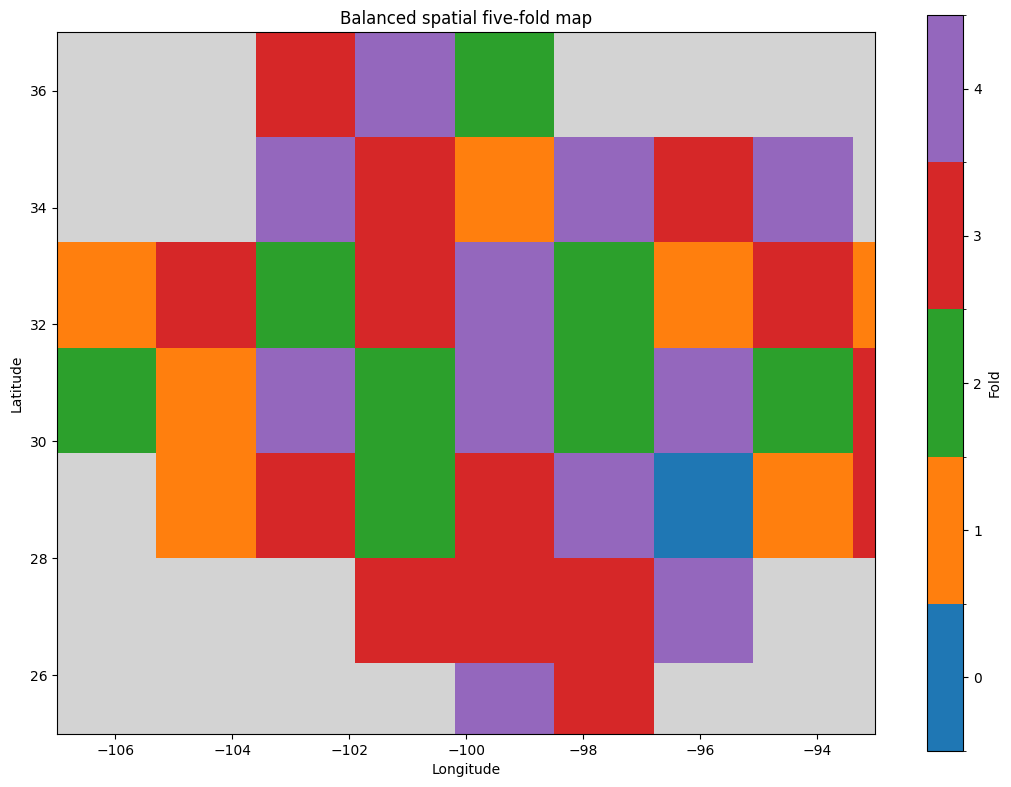

In [65]:
from matplotlib.colors import BoundaryNorm, ListedColormap

fold_cmap = ListedColormap([
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
])

fold_cmap.set_bad(
    color="lightgray"
)

fold_display = np.ma.masked_where(
    fold_map < 0,
    fold_map,
)

norm = BoundaryNorm(
    np.arange(-0.5, 5.5, 1),
    fold_cmap.N,
)

plt.figure(figsize=(11, 8))

image = plt.imshow(
    fold_display,
    extent=extent_plot,
    origin="upper",
    cmap=fold_cmap,
    norm=norm,
    interpolation="nearest",
)

plt.colorbar(
    image,
    ticks=range(5),
    label="Fold",
)

plt.title("Balanced spatial five-fold map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

## 14. Ablation Experiments

In [66]:
experiments = {
    "E0_environmental": environmental_features,
    "E1_environmental_tweet_count": np.concatenate(
        [environmental_features, tweet_count_norm[None]], axis=0),
    "E3_environmental_semantic": np.concatenate(
        [environmental_features, semantic_features_norm], axis=0),
    "E4_environmental_semantic_tweet_count": np.concatenate(
        [environmental_features, semantic_features_norm, tweet_count_norm[None]], axis=0),
}
if single_flood_relevance_norm is None:
    warnings.warn("E2 skipped: set CONFIG['single_flood_relevance_raster'] to enable it.")
else:
    experiments["E2_environmental_flood_relevance"] = np.concatenate(
        [environmental_features, single_flood_relevance_norm[None]], axis=0)

all_results, all_histories, all_states = [], {}, {}
for name, features in experiments.items():
    result, histories, states = run_spatial_cv_experiment(name, features, y_full, fold_map, CONFIG)
    all_results.append(result); all_histories[name] = histories; all_states[name] = states
comparison = pd.concat(all_results, ignore_index=True)
summary = comparison.groupby("experiment").agg(
    mean_MAE=("MAE", "mean"), std_MAE=("MAE", "std"),
    mean_RMSE=("RMSE", "mean"), std_RMSE=("RMSE", "std"),
    mean_R2=("R2", "mean"), std_R2=("R2", "std"),
).reset_index()
CONFIG["cv_results_path"].parent.mkdir(parents=True, exist_ok=True)
comparison.to_csv(CONFIG["cv_results_path"], index=False)
summary.to_csv(CONFIG["cv_summary_path"], index=False)
display(comparison); display(summary)

/tmp/ipykernel_553/1887050617.py:11: UserWarning: E2 skipped: set CONFIG['single_flood_relevance_raster'] to enable it.
  warnings.warn("E2 skipped: set CONFIG['single_flood_relevance_raster'] to enable it.")


,experiment,fold,best_epoch,MAE,RMSE,R2
0,E0_environmental,1,34,0.206765,0.552264,0.820136
1,E0_environmental,2,39,0.075616,0.316176,0.840917
2,E0_environmental,3,50,0.016998,0.141515,0.907834
3,E0_environmental,4,34,0.002916,0.041416,0.773013
4,E0_environmental,5,4,0.024365,0.150453,0.871102
5,E1_environmental_tweet_count,1,27,0.230142,0.558919,0.815775
6,E1_environmental_tweet_count,2,43,0.081233,0.305931,0.851059
7,E1_environmental_tweet_count,3,26,0.019700,0.154604,0.889996
8,E1_environmental_tweet_count,4,46,0.002828,0.039380,0.794782
9,E1_environmental_tweet_count,5,13,0.020014,0.133932,0.897856


,experiment,mean_MAE,std_MAE,mean_RMSE,std_RMSE,mean_R2,std_R2
0,E0_environmental,0.065332,0.083695,0.240365,0.200290,0.842600,0.051034
1,E1_environmental_tweet_count,0.070783,0.093954,0.238553,0.203001,0.849894,0.045031
2,E3_environmental_semantic,0.062720,0.082001,0.223671,0.192094,0.859222,0.063508
3,E4_environmental_semantic_tweet_count,0.058608,0.075306,0.219061,0.188478,0.881203,0.031018


## 15. Final Model Training

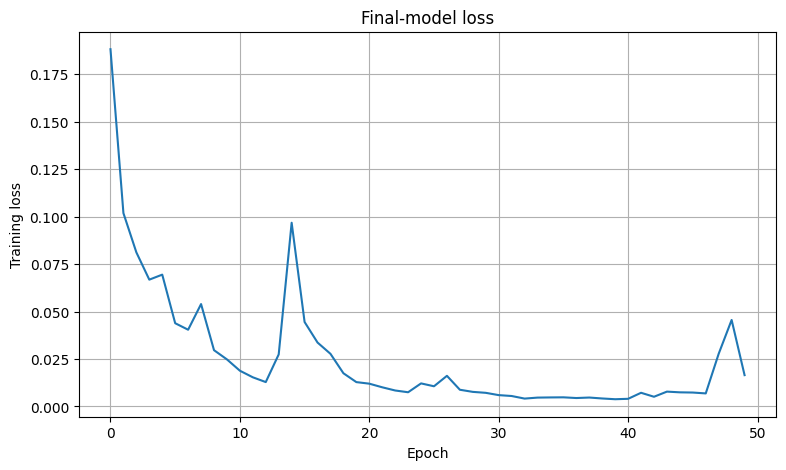

In [67]:
final_X = experiments["E4_environmental_semantic_tweet_count"]
final_model, final_loss_history = train_final_model(final_X, y_full, CONFIG)
CONFIG["final_model_path"].parent.mkdir(parents=True, exist_ok=True)
torch.save(final_model.state_dict(), CONFIG["final_model_path"])
plt.figure(figsize=(9, 5)); plt.plot(final_loss_history)
plt.xlabel("Epoch"); plt.ylabel("Training loss"); plt.title("Final-model loss"); plt.grid(True); plt.show()

## 16. Full-Map Overlap Prediction

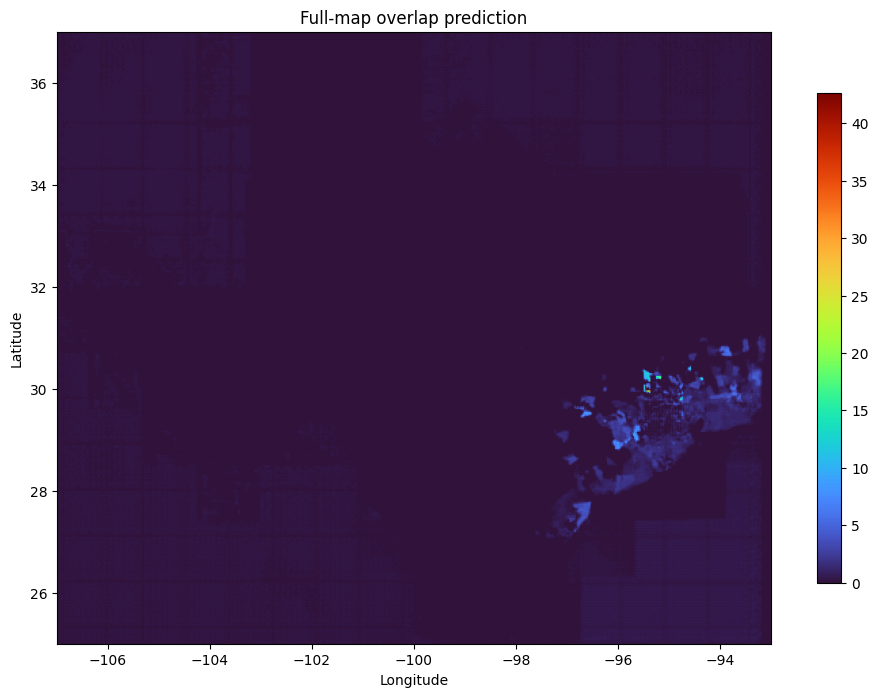

In [68]:
pred_full = predict_full_map_overlap(
    final_model, final_X, CONFIG["patch_size"], CONFIG["stride"],
    CONFIG["unet_batch_size"], DEVICE)
assert pred_full.shape == y_full.shape
show_raster(pred_full, "Full-map overlap prediction", "turbo")

## 17. Texas Boundary Clipping

In [72]:
CONFIG["texas_boundary_file"] = (
    "/content/drive/MyDrive/Data/tl_2025_48_tract"
)

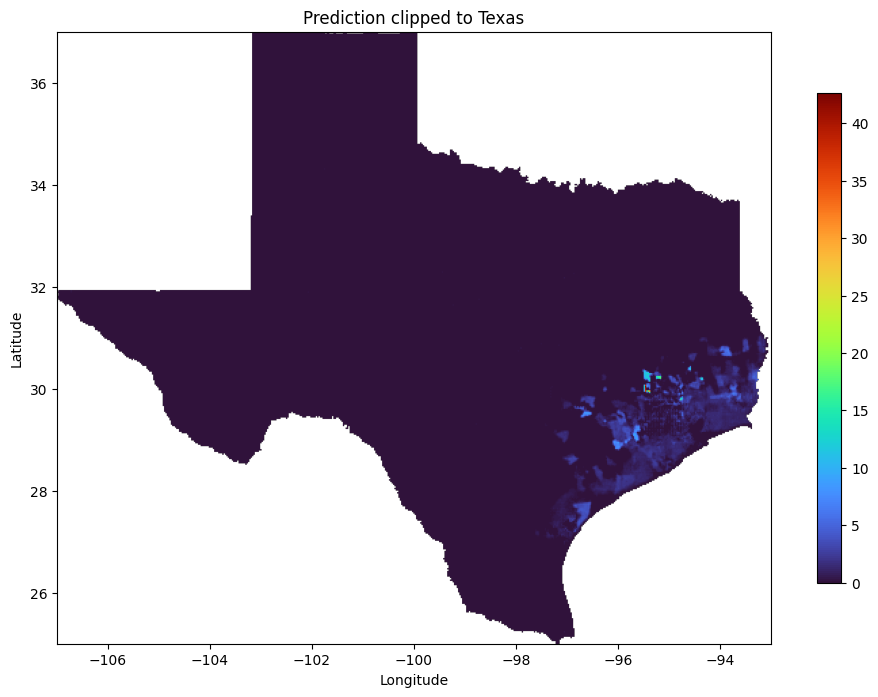

In [73]:
import geopandas as gpd
boundary_path = require_path(CONFIG["texas_boundary_file"], "texas_boundary_file")
texas = gpd.read_file(boundary_path).to_crs(water_025_crs)
texas_union = texas.geometry.union_all() if hasattr(texas.geometry, "union_all") else texas.unary_union
texas_mask = geometry_mask([texas_union], out_shape=pred_full.shape,
                           transform=water_025_transform, invert=True)
pred_full_tx = np.where(texas_mask, pred_full, np.nan)
show_raster(pred_full_tx, "Prediction clipped to Texas", "turbo")

## 18. GeoTIFF Export

In [74]:
profile = target_profile.copy()
profile.update(driver="GTiff", dtype="float32", count=1, nodata=-9999.0, compress="lzw")
CONFIG["prediction_path"].parent.mkdir(parents=True, exist_ok=True)
saved = np.where(np.isfinite(pred_full_tx), pred_full_tx, -9999.0).astype(np.float32)
with rasterio.open(CONFIG["prediction_path"], "w", **profile) as dst:
    dst.write(saved, 1)
    dst.set_band_description(1, "U-Net fine-resolution flood depth")
print("Saved:", CONFIG["prediction_path"])

Saved: outputs/pred_full_texas.tif


## 19. Results and Diagnostics

Prediction finite cells: 225029
Full-map MAE: 0.02399032
Full-map RMSE: 0.15733579


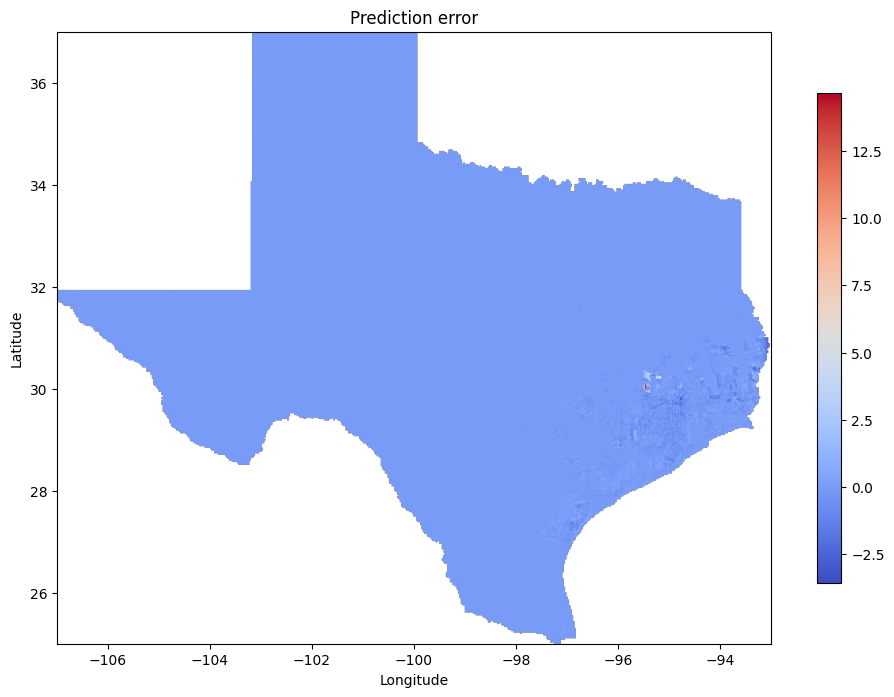

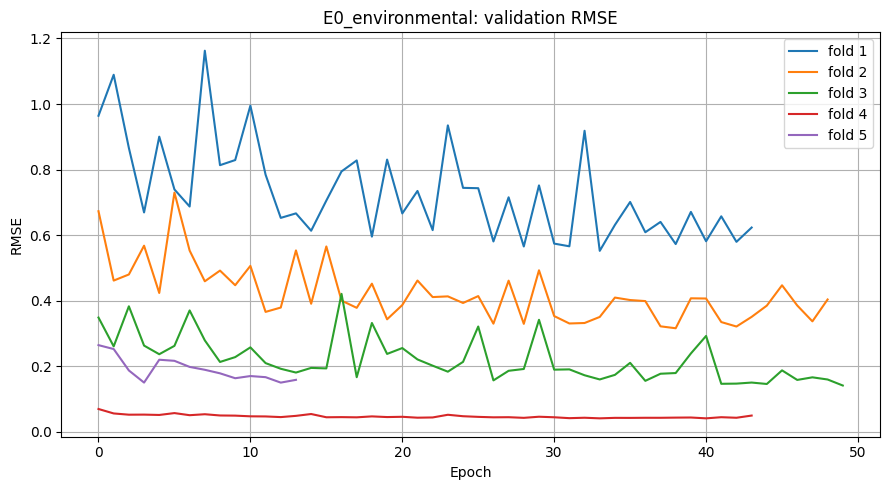

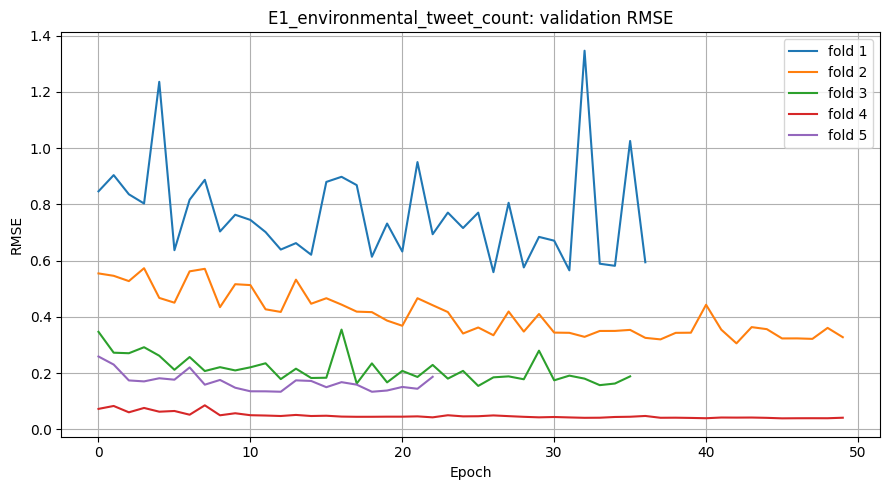

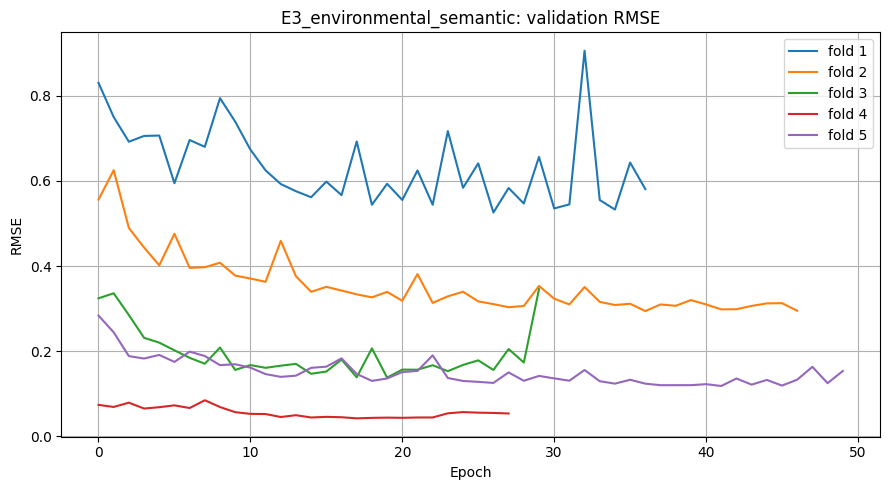

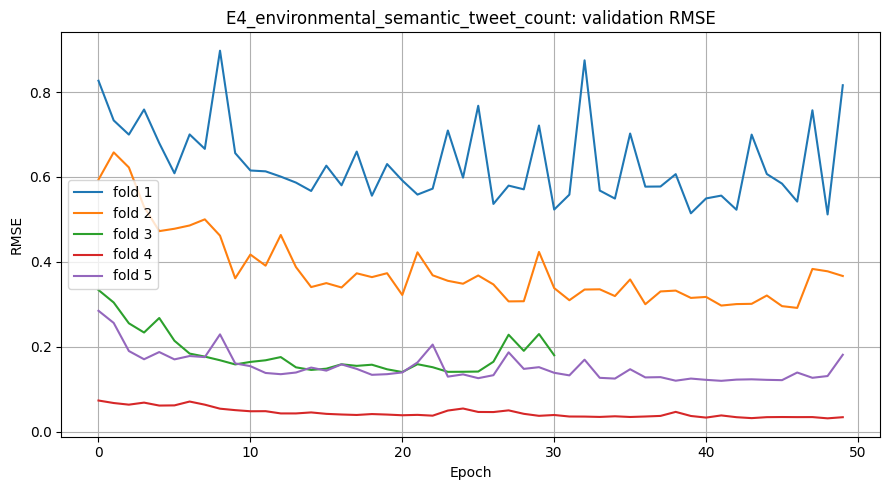

In [75]:
error = pred_full - y_full
valid = np.isfinite(error)
print("Prediction finite cells:", np.isfinite(pred_full).sum())
if valid.any():
    print("Full-map MAE:", np.mean(np.abs(error[valid])))
    print("Full-map RMSE:", np.sqrt(np.mean(error[valid] ** 2)))
show_raster(error, "Prediction error", "coolwarm")
for experiment, folds in all_histories.items():
    plt.figure(figsize=(9, 5))
    for fold, history in folds.items():
        plt.plot(history["val_rmse"], label=f"fold {fold}")
    plt.title(f"{experiment}: validation RMSE"); plt.xlabel("Epoch"); plt.ylabel("RMSE")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()